Fig2A


data num: 98
Paired t-test for Change 0: t=8.5181, p=2.1016e-13
Paired t-test for Change 3: t=7.6083, p=1.8072e-11


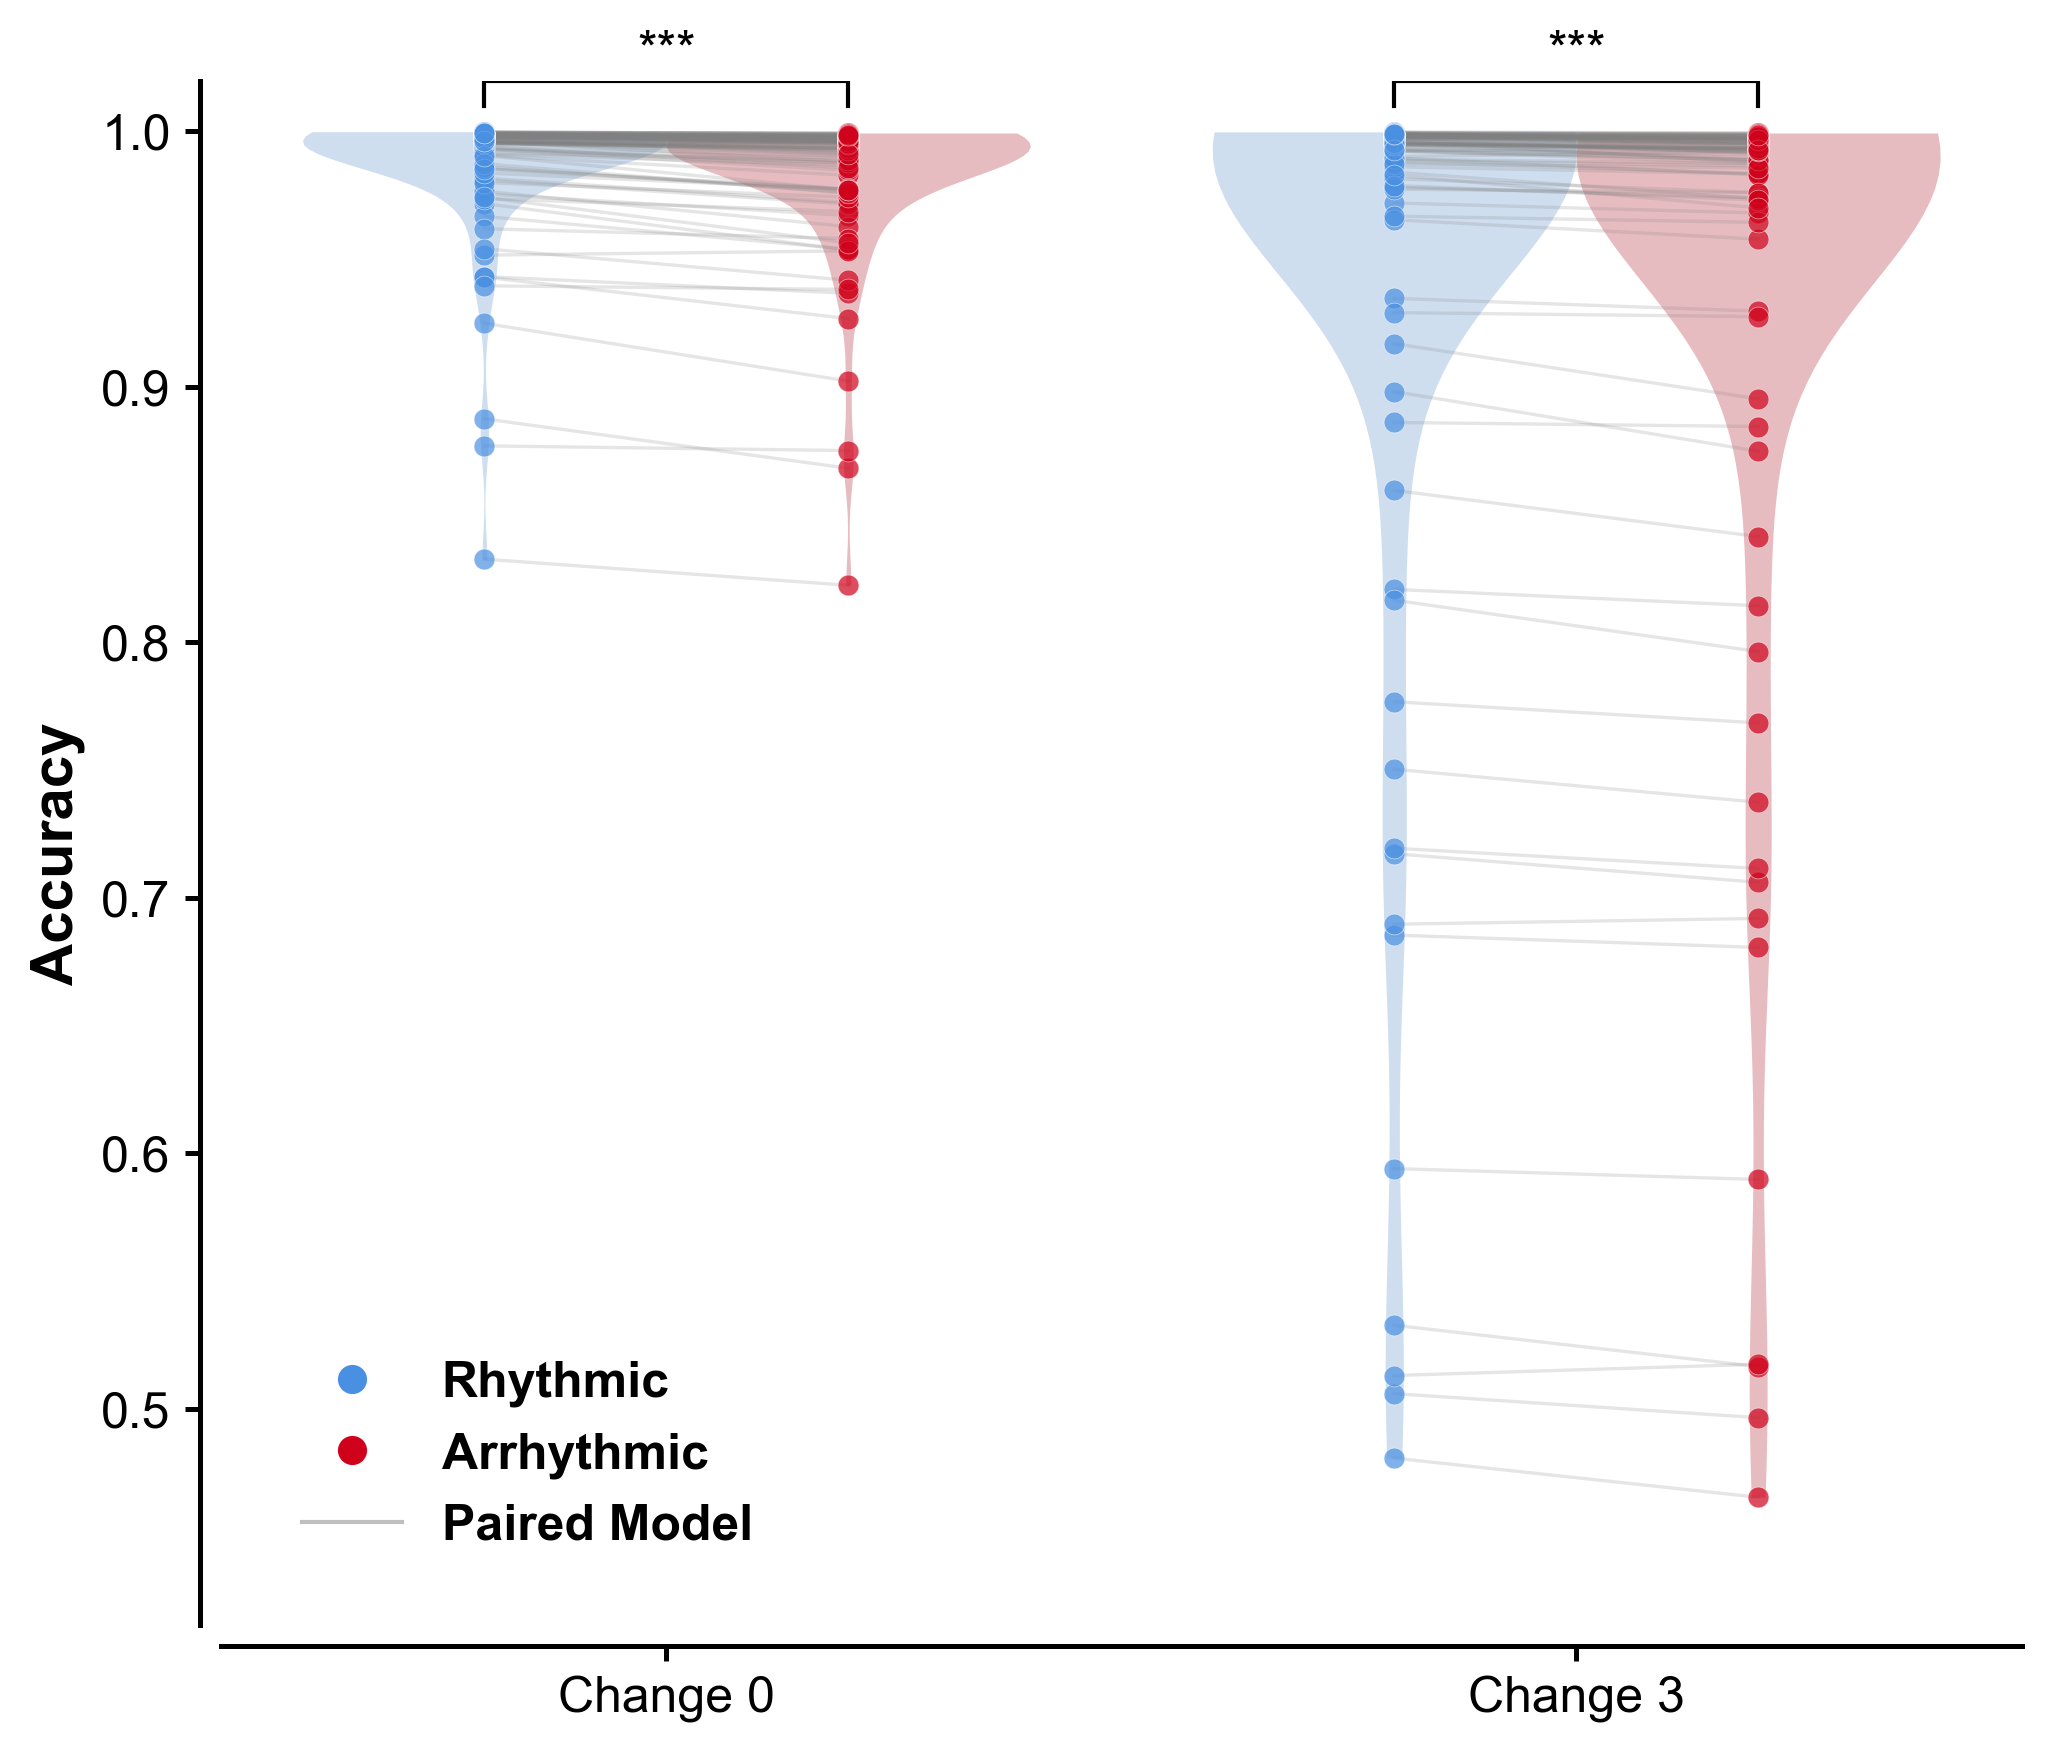

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

df = pd.read_csv(r'./STSP_RNN_stim6results_30-100_tvu/all_results_averaged.csv')
print(f"data num: {len(df)}")

def prepare_data_long(df):
    data_list = []
    config = [
        ('Rhythmic_Change_0', 'Rhythmic', 'Change 0'),
        ('Arrhythmic_Change_0', 'Arrhythmic', 'Change 0'),
        ('Rhythmic_Change_3', 'Rhythmic', 'Change 3'),
        ('Arrhythmic_Change_3', 'Arrhythmic', 'Change 3')
    ]
    for col, rhy, change in config:
        if col in df.columns:
            sub = pd.DataFrame({
                'Accuracy': df[col],
                'Rhythmicity': rhy,
                'Change_Type': change
            })
            data_list.append(sub)
    return pd.concat(data_list, ignore_index=True)

df_long = prepare_data_long(df)
df_long.dropna(inplace=True)


def add_significance_bar(ax, x1, x2, y, p_value):
    h = 0.01 
    if p_value >= 0.05: text = 'n.s.'
    elif p_value < 0.001: text = '***'
    elif p_value < 0.01: text = '**'
    elif p_value < 0.05: text = '*'
    else: text = 'n.s.'
    
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1, c='k')
    ax.text((x1 + x2) * 0.5, y + 0.002, text, ha='center', va='bottom', color='k', fontsize=12)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
palette = {'Rhythmic': '#4A90E2', 'Arrhythmic': '#D0021B'}

sns.violinplot(data=df_long, x='Change_Type', y='Accuracy', hue='Rhythmicity',
               split=False, inner=None, cut=0, palette=palette,
               alpha=0.3, linewidth=0, width=0.8, ax=ax, density_norm='width', saturation=0.7)

offset = 0.2
x_centers = [0, 1]

for idx, row in df.iterrows():

    x_rhy_0 = x_centers[0] - offset
    x_arr_0 = x_centers[0] + offset
    ax.plot([x_rhy_0, x_arr_0], 
            [row['Rhythmic_Change_0'], row['Arrhythmic_Change_0']], 
            color='gray', alpha=0.2, linewidth=0.8, zorder=1)

    x_rhy_3 = x_centers[1] - offset
    x_arr_3 = x_centers[1] + offset
    ax.plot([x_rhy_3, x_arr_3], 
            [row['Rhythmic_Change_3'], row['Arrhythmic_Change_3']], 
            color='gray', alpha=0.2, linewidth=0.8, zorder=1)


ax.scatter(np.full(len(df), x_centers[0] - offset), df['Rhythmic_Change_0'], 
           color=palette['Rhythmic'], s=25, alpha=0.7, edgecolor='white', linewidth=0.15, zorder=2)
ax.scatter(np.full(len(df), x_centers[0] + offset), df['Arrhythmic_Change_0'], 
           color=palette['Arrhythmic'], s=25, alpha=0.7, edgecolor='white', linewidth=0.15, zorder=2)

ax.scatter(np.full(len(df), x_centers[1] - offset), df['Rhythmic_Change_3'], 
           color=palette['Rhythmic'], s=25, alpha=0.7, edgecolor='white', linewidth=0.15, zorder=2)
ax.scatter(np.full(len(df), x_centers[1] + offset), df['Arrhythmic_Change_3'], 
           color=palette['Arrhythmic'], s=25, alpha=0.7, edgecolor='white', linewidth=0.15, zorder=2)



y_max_base = df_long['Accuracy'].max()

stat0, p0 = stats.ttest_rel(df['Rhythmic_Change_0'], df['Arrhythmic_Change_0'])
print(f"Paired t-test for Change 0: t={stat0:.4f}, p={p0:.4e}")
add_significance_bar(ax, x_centers[0] - offset, x_centers[0] + offset, y_max_base + 0.02, p0)

stat3, p3 = stats.ttest_rel(df['Rhythmic_Change_3'], df['Arrhythmic_Change_3'])
print(f"Paired t-test for Change 3: t={stat3:.4f}, p={p3:.4e}")
add_significance_bar(ax, x_centers[1] - offset, x_centers[1] + offset, y_max_base + 0.02, p3)


from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Rhythmic',
           markerfacecolor=palette['Rhythmic'], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Arrhythmic',
           markerfacecolor=palette['Arrhythmic'], markersize=8),
    Line2D([0], [0], color='gray', lw=1, label='Paired Model', alpha=0.5)
]

ax.legend(handles=legend_elements, 
          loc='lower left', 
          bbox_to_anchor=(0.02, 0.02), 
          frameon=False, 
          ncol=1, 
          fontsize=12)

plt.setp(ax.get_legend().get_texts(), fontweight='bold')

ax.set_xlabel('', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')

y_min = df_long['Accuracy'].min()
ax.set_ylim(bottom=y_min - 0.05, top=y_max_base + 0.02)

sns.despine(offset=5, trim=False)

plt.tight_layout()
plt.savefig(r'./rhythm_arrhythm_accuracy_paired_with_lines.pdf', format='pdf', transparent=True)
plt.show()

Fig2B


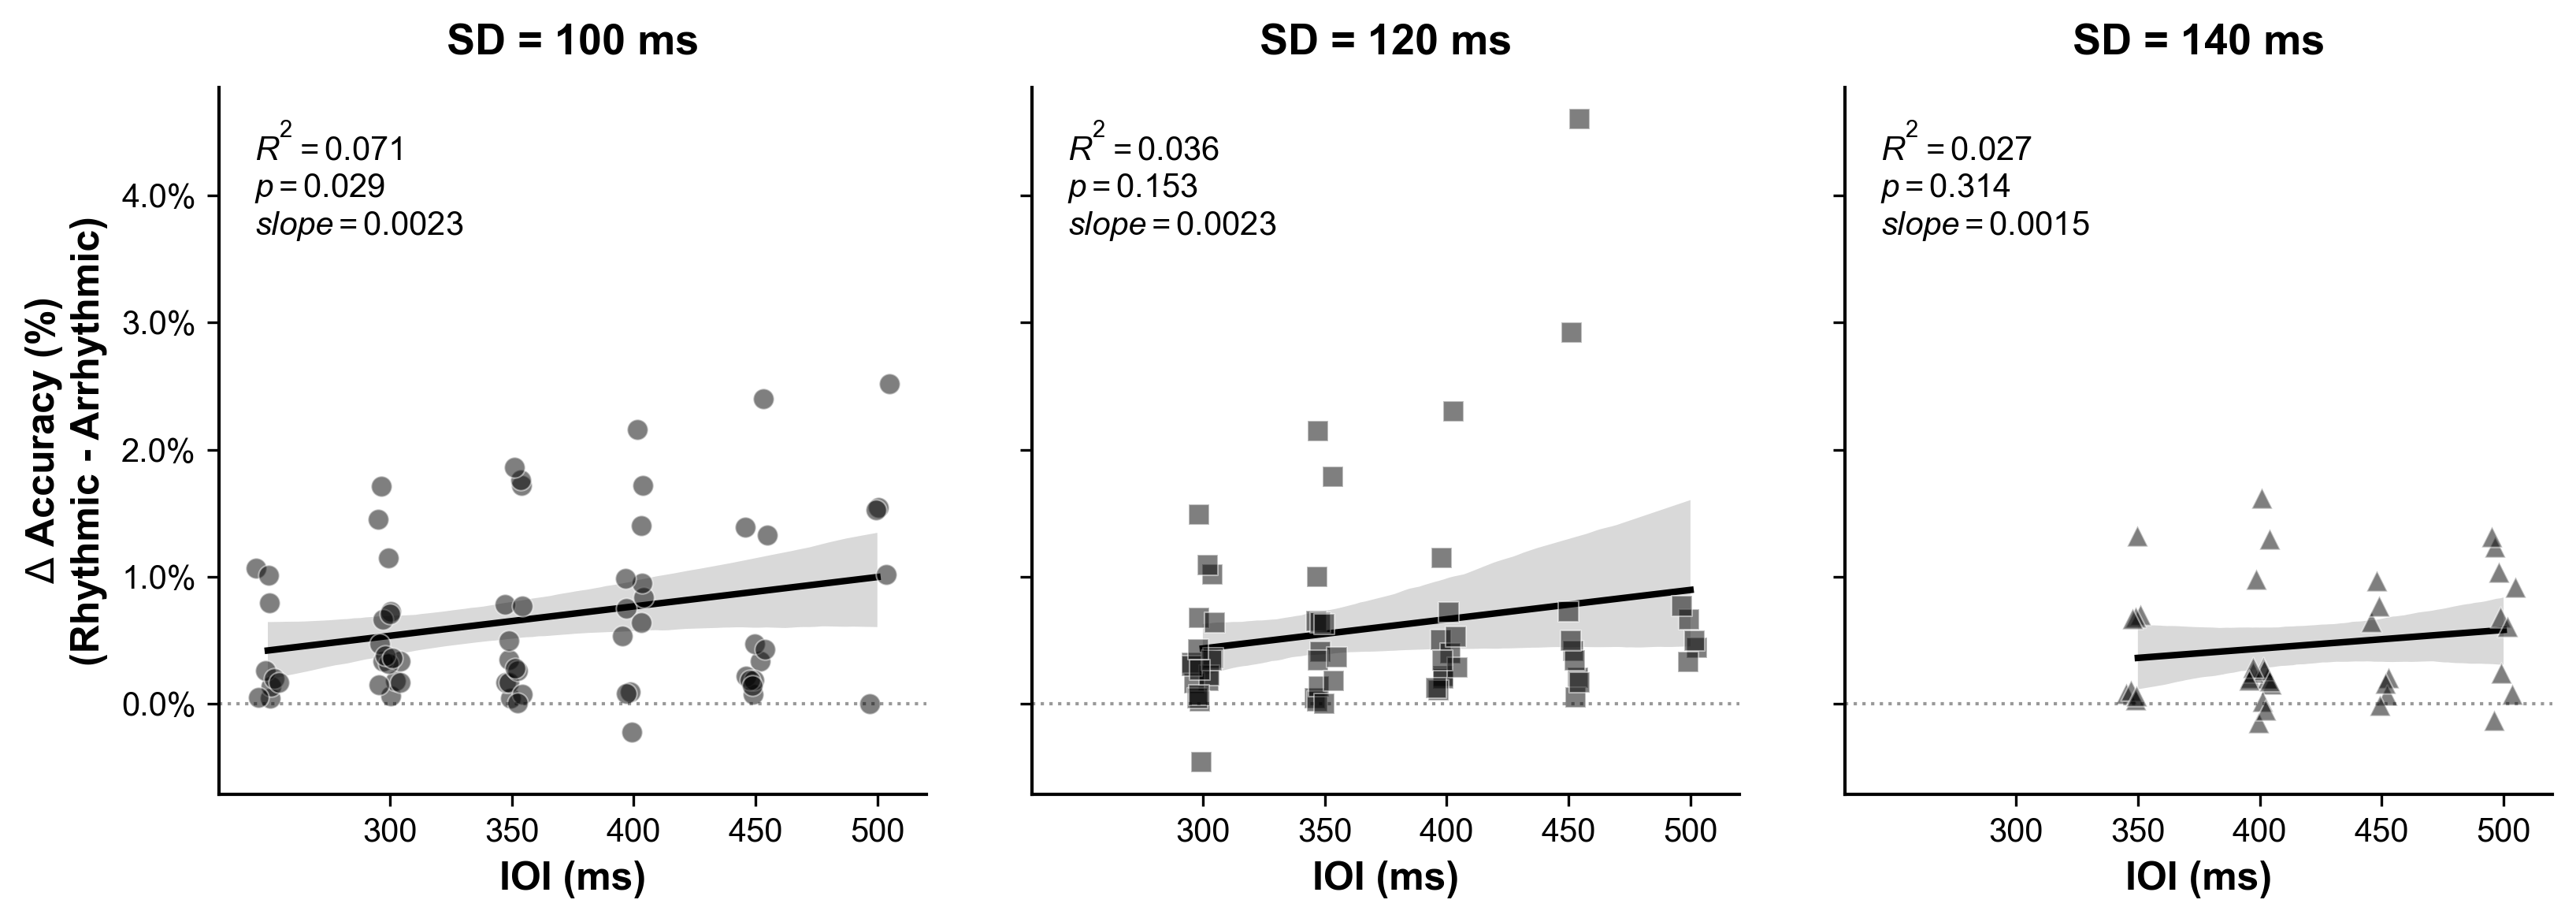

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.ticker as ticker

df = pd.read_csv(r'./STSP_RNN_stim6results_30-100_tvu/all_results_averaged.csv')

def parse_config(config_str):
    parts = config_str.split('-')
    if len(parts) >= 2:
        return int(parts[0]), int(parts[1])
    return None, None

df['SD'] = df['params'].apply(lambda x: parse_config(x)[0])
df['IOI'] = df['params'].apply(lambda x: parse_config(x)[1])
df['rhythm_delta'] = df['Rhythmic_Only'] - df['Arrhythmic_Only']

df['rhythm_delta_pct'] = df['rhythm_delta'] * 100

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

# Create canvas
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True, dpi=300)

colors = {100: "#000000", 120: "#000000", 140: "#000000"}
markers = {100: 'o', 120: 's', 140: '^'}
sd_list = [100, 120, 140]

def format_slope(val):
    if abs(val) < 0.001 and val != 0:
        return f"{val:.1e}"
    else:
        return f"{val:.4f}"

for i, sd in enumerate(sd_list):
    ax = axes[i]
    subset = df[df['SD'] == sd]
    color = colors[sd]
    
    y_col = 'rhythm_delta_pct'
    
    sns.regplot(
        data=subset, x='IOI', y=y_col,
        ax=ax, scatter=False, ci=95,
        line_kws={'color': color, 'linewidth': 2},
        color=color
    )
    
    x_jitter = subset['IOI'] + np.random.uniform(-5, 5, size=len(subset))
    ax.scatter(
        x_jitter, subset[y_col],
        color=color, marker=markers[sd], s=40, alpha=0.5,
        edgecolor='white', linewidth=0.5, zorder=2
    )
    
    slope, intercept, r_val, p_val, stderr = linregress(subset['IOI'], subset[y_col])
    
    p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"
    slope_text = format_slope(slope)
    
    stats_text = (f"$R^2 = {r_val**2:.3f}$\n"
                  f"${p_text}$\n"
                  f"$slope = {slope_text}$")
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle='square,pad=0', fc='none', ec='none'))

    ax.set_title(f'SD = {sd} ms', fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks([300, 350, 400, 450, 500])

    ax.grid(axis='x', visible=False)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    
    ax.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.4)
    ax.set_xlim(230, 520)

    if i == 0:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=1))

axes[0].set_ylabel('$\Delta$ Accuracy (%)\n(Rhythmic - Arrhythmic)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('IOI (ms)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('IOI (ms)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('IOI (ms)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()